# Multi-Asset Portfolio Optimization: Equities + Crypto + FX

**Universe (8 assets).** AAPL, MSFT, XOM, JPM, KO (equities), BTC (crypto),
EUR/USD and JPY/USD (FX), over 2010-07-19 to 2016-12-30 — the window where all
three data sources overlap.

**Data sources.**
- Equities: `https://raw.githubusercontent.com/kyi3081/stock-analysis/master/prices-split-adjusted.csv`
- BTC: `https://raw.githubusercontent.com/Habrador/Bitcoin-price-visualization/main/Bitcoin-price-USD.csv`
- FX: `https://raw.githubusercontent.com/datasets/exchange-rates/main/data/daily.csv` (U.S. Federal Reserve H.10 release)

**Method.** Split the sample in half. Estimate expected returns and the
covariance matrix on the **training** half only; construct four portfolios
(minimum-variance, maximum-Sharpe/tangency, equal-weight, and risk-parity)
using only that in-sample information; then evaluate all four **out of
sample** on the untouched second half — the discipline that separates a real
backtest from curve-fitting.


In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
%matplotlib inline


## 1. Load and align all three asset classes on a common calendar

In [2]:
eq = pd.read_csv("../data/nyse_prices.csv", parse_dates=["date"])
eq = eq.pivot(index="date", columns="symbol", values="close").sort_index()
tickers_eq = ["AAPL", "MSFT", "XOM", "JPM", "KO"]
eq = eq[tickers_eq]

btc = pd.read_csv("../data/btc_price.csv", parse_dates=["Date"]).set_index("Date")["Price"]
btc.name = "BTC"

fx = pd.read_csv("../data/fx_daily.csv", parse_dates=["Date"])
eur = fx[fx["Country"] == "Euro"].set_index("Date")["Exchange rate"].rename("EURUSD")
jpy = fx[fx["Country"] == "Japan"].set_index("Date")["Exchange rate"].rename("JPYUSD")

prices = pd.concat([eq, btc, eur, jpy], axis=1, sort=True)
prices = prices.loc[eq.index.min():eq.index.max()]
prices = prices.reindex(eq.index).ffill().dropna()
assets = list(prices.columns)
print(f"Universe: {assets}")
print(f"Sample: {prices.index.min().date()} to {prices.index.max().date()} ({len(prices)} days)")

rets = np.log(prices / prices.shift(1)).dropna()


Universe: ['AAPL', 'MSFT', 'XOM', 'JPM', 'KO', 'BTC', 'EURUSD', 'JPYUSD']
Sample: 2010-07-19 to 2016-12-30 (1627 days)


In [3]:
split = len(rets) // 2
train, test = rets.iloc[:split], rets.iloc[split:]
print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} days)")
print(f"Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} days)")

mu = train.mean().values * 252
cov = train.cov().values * 252
n = len(assets)

print("\nAnnualized expected return (in-sample) by asset:")
pd.Series(mu, index=assets).round(3)


Train: 2010-07-20 to 2013-10-09 (813 days)
Test:  2013-10-10 to 2016-12-30 (813 days)

Annualized expected return (in-sample) by asset:


AAPL      0.212
MSFT      0.084
XOM       0.117
JPM       0.081
KO        0.108
BTC       2.282
EURUSD   -0.013
JPYUSD    0.035
dtype: float64

> **Note the BTC return.** BTC's annualized log return over the 2010–2013
> training window (~228%) reflects its actual, real price history: it traded
> for cents in mid-2010 and crossed into the hundreds of dollars by late 2013.
> That's a genuine, extreme feature of this specific historical window, not a
> data error — and it's exactly the kind of input that historical
> mean-return estimation is fragile to, a point the out-of-sample test below
> speaks to directly.

## 2. Efficient frontier (long-only)

In [4]:
def solve_min_var(target_return=None, long_only=True):
    w = cp.Variable(n)
    risk = cp.quad_form(w, cp.psd_wrap(cov))
    constraints = [cp.sum(w) == 1]
    if long_only:
        constraints.append(w >= 0)
    if target_return is not None:
        constraints.append(mu @ w >= target_return)
    prob = cp.Problem(cp.Minimize(risk), constraints)
    prob.solve()
    return w.value

target_returns = np.linspace(mu.min() * 0.9, mu.max() * 0.98, 40)
frontier_vol, frontier_ret, frontier_weights = [], [], []
for tr in target_returns:
    w = solve_min_var(target_return=tr)
    if w is None:
        continue
    frontier_vol.append(np.sqrt(w @ cov @ w))
    frontier_ret.append(mu @ w)
    frontier_weights.append(w)
print(f"Solved {len(frontier_weights)} points on the efficient frontier")


Solved 40 points on the efficient frontier


## 3. Four named portfolios: Min-Variance, Max-Sharpe, Equal-Weight, Risk-Parity

In [5]:
rf = 0.02
w_minvar = solve_min_var()

sharpe_grid = [(r - rf) / v if v > 0 else -np.inf for r, v in zip(frontier_ret, frontier_vol)]
best_idx = int(np.argmax(sharpe_grid))
w_tangency = frontier_weights[best_idx]

w_ew = np.ones(n) / n

def risk_parity_weights(cov, n_iter=500, lr=0.01):
    w = np.ones(len(cov)) / len(cov)
    for _ in range(n_iter):
        port_vol = np.sqrt(w @ cov @ w)
        mrc = cov @ w / port_vol
        rc = w * mrc
        target = port_vol / len(cov)
        grad = rc - target
        w = w - lr * grad
        w = np.clip(w, 1e-4, None)
        w = w / w.sum()
    return w

w_rp = risk_parity_weights(cov)

def port_stats(w, mu, cov):
    r = mu @ w
    v = np.sqrt(w @ cov @ w)
    return r, v, (r - rf) / v

portfolios = pd.DataFrame({
    "Min-Variance": w_minvar,
    "Max-Sharpe (tangency)": w_tangency,
    "Equal-Weight": w_ew,
    "Risk-Parity": w_rp,
}, index=assets)
portfolios.round(3)


,Min-Variance,Max-Sharpe (tangency),Equal-Weight,Risk-Parity
AAPL,0.017,0.289,0.125,0.109
MSFT,0.035,-0.000,0.125,0.114
XOM,0.114,-0.000,0.125,0.122
JPM,0.000,-0.000,0.125,0.088
KO,0.103,0.403,0.125,0.141
BTC,0.001,0.200,0.125,0.028
EURUSD,0.479,0.000,0.125,0.216
JPYUSD,0.251,0.108,0.125,0.183


In [6]:
is_stats = pd.DataFrame({name: port_stats(portfolios[name].values, mu, cov)
                          for name in portfolios.columns},
                         index=["exp_return", "exp_vol", "sharpe"]).T
print("In-sample expected stats:")
is_stats.round(3)


In-sample expected stats:


,exp_return,exp_vol,sharpe
Min-Variance,0.037,0.059,0.283
Max-Sharpe (tangency),0.565,0.286,1.903
Equal-Weight,0.363,0.198,1.737
Risk-Parity,0.136,0.101,1.151


## 4. Out-of-sample backtest

In [7]:
oos_growth = {}
oos_stats = {}
for name in portfolios.columns:
    w = portfolios[name].values
    port_ret = pd.Series(test.values @ w, index=test.index)
    oos_growth[name] = (1 + port_ret).cumprod()
    ann_ret = (1 + port_ret).prod() ** (252 / len(port_ret)) - 1
    ann_vol = port_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol
    cum = (1 + port_ret).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    oos_stats[name] = (ann_ret, ann_vol, sharpe, max_dd)

oos_df = pd.DataFrame(oos_growth, index=test.index)
oos_stats_df = pd.DataFrame(oos_stats, index=["ann_return", "ann_vol", "sharpe", "max_drawdown"]).T
print("Out-of-sample performance (test half):")
oos_stats_df.round(3)


Out-of-sample performance (test half):


,ann_return,ann_vol,sharpe,max_drawdown
Min-Variance,0.066,0.074,0.628,-0.080
Max-Sharpe (tangency),0.189,0.191,0.887,-0.264
Equal-Weight,0.170,0.142,1.056,-0.175
Risk-Parity,0.106,0.098,0.881,-0.110


## 5. Charts

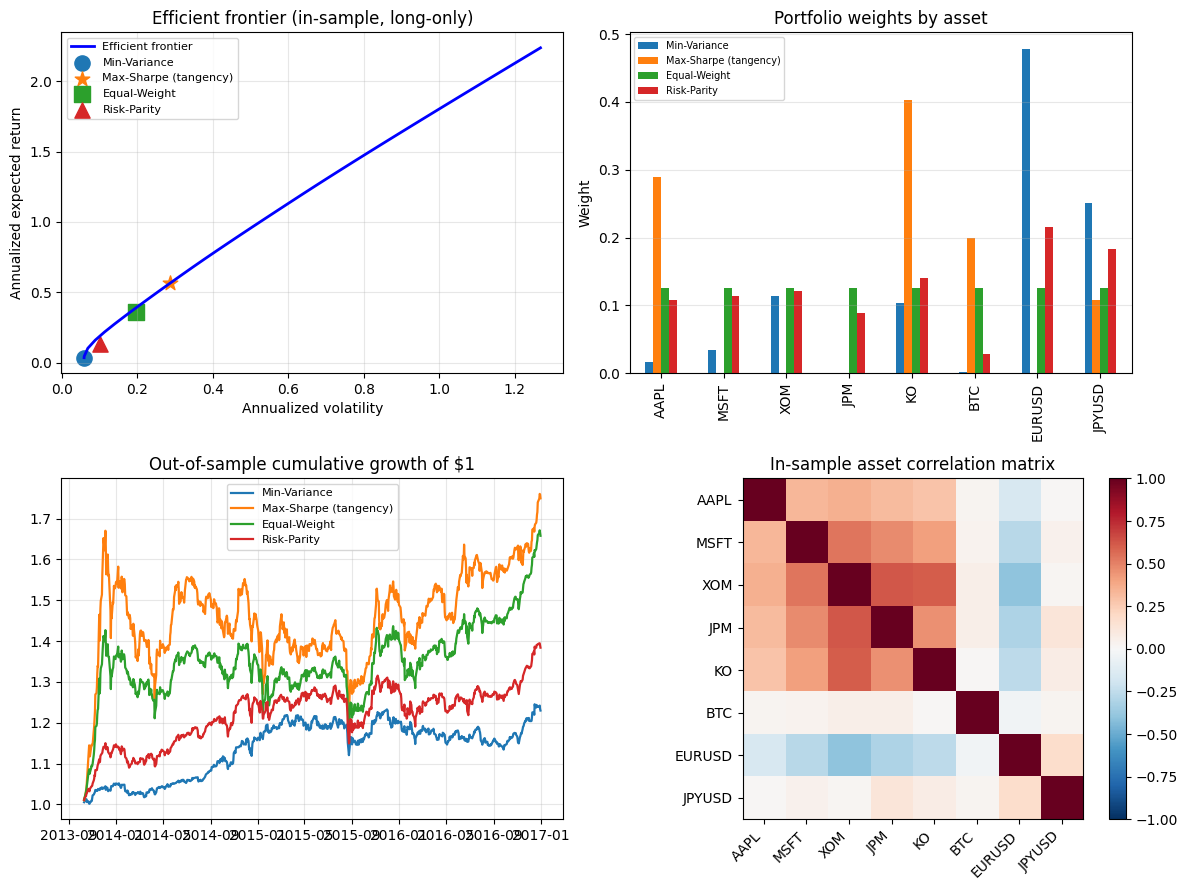

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(frontier_vol, frontier_ret, "b-", lw=2, label="Efficient frontier")
for name, marker in zip(portfolios.columns, ["o", "*", "s", "^"]):
    r, v, _ = port_stats(portfolios[name].values, mu, cov)
    axes[0, 0].scatter(v, r, marker=marker, s=120, label=name)
axes[0, 0].set_xlabel("Annualized volatility")
axes[0, 0].set_ylabel("Annualized expected return")
axes[0, 0].set_title("Efficient frontier (in-sample, long-only)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

portfolios.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Portfolio weights by asset")
axes[0, 1].set_ylabel("Weight")
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(alpha=0.3, axis="y")

for name in oos_df.columns:
    axes[1, 0].plot(oos_df.index, oos_df[name], label=name, lw=1.6)
axes[1, 0].set_title("Out-of-sample cumulative growth of $1")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

corr = train.corr()
im = axes[1, 1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1, 1].set_xticks(range(n)); axes[1, 1].set_xticklabels(assets, rotation=45, ha="right")
axes[1, 1].set_yticks(range(n)); axes[1, 1].set_yticklabels(assets)
axes[1, 1].set_title("In-sample asset correlation matrix")
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.savefig("portfolio_optimization_results.png", dpi=110)
plt.show()


## 6. Discussion

- **In-sample optimization looks great; out-of-sample it degrades — as it
  should.** The max-Sharpe (tangency) portfolio's in-sample Sharpe (~1.9,
  driven heavily by BTC's extreme training-period return) falls to well under
  half that out of sample. This is the textbook failure mode of mean-variance
  optimization: it's very sensitive to estimated expected returns, and
  historical means are noisy, especially over a training window containing an
  outlier asset like early-history BTC.
- **Risk-parity is the most stable across samples.** Because it only uses the
  covariance matrix (not expected returns) to size positions, its in-sample
  and out-of-sample Sharpe ratios are much closer together (1.15 → 0.88) than
  the tangency portfolio's (1.90 → 0.89) — a well-documented reason risk
  parity is popular in practice despite its "naive" optimality on paper.
- **The correlation matrix explains a lot.** FX and equities are weakly
  correlated in this sample, which is why the minimum-variance solution leans
  so heavily on EUR/USD and JPY/USD — they're doing real diversification work,
  not just adding low-volatility exposure.
- **Honest limitations:** no rebalancing costs are modeled between
  observations, expected returns are simple historical means (a real desk
  would blend in views, e.g. Black-Litterman), and BTC's extreme early
  volatility is a genuine outlier that a live risk process would likely cap
  or treat separately.
